In [1]:
%load_ext autoreload
%autoreload 2

In [4]:
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt

from ir_risk import *

In [26]:
sim = SimParams(dt=1/252, n_paths=2000, seed=42)
cfg = MetricConfig(nii_horizon=1.0, pv_horizon=30.0, shock=0.01)

# 1) ΔNII
d = delta_nii_parallel_shock(model=model, balance=bal, spread=spread, sim=sim, cfg=cfg, measure_for_paths="P")
print("ΔNII:", d)

# 2) FV (no default), under Q
fv = fair_value(model=model, balance=bal, spread=spread, sim=sim, cfg=cfg, measure_for_discounting="Q")
print("FV:", fv)

# 3) FV with default stop, under Q
fvd = fair_value_with_default(model=model, balance=bal, spread=spread, sim=sim, cfg=cfg, measure_for_discounting="Q")
print("FV default:", fvd)

ΔNII: {'E_NII_base': -0.06467816382673289, 'E_NII_shock': -0.07374487669536992, 'Delta_NII': -0.00906671286863703}
FV: {'E_FV': -0.20554437043130322, 'Std_FV': 0.054518791778241274}
FV default: {'E_FV_default': -0.048234425886829635, 'Std_FV_default': 0.00043670269341825995, 'P_default_by_H': 1.0}


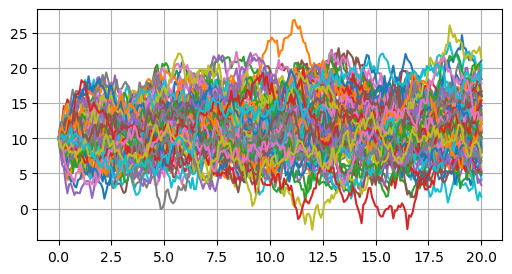

In [131]:
# Choose model
params = RateParams(
    kappa=0.3,
    theta_P=0.12,
    theta_Q=0.12,   # only difference: long-run mean under Q
    sigma=0.03,
    r0=0.1
)
model = VasicekModel(params)  # or CIRModel(params)

T = 20.0
dt = 1/12
n_paths = 1000
rates = model.simulate(T=T, dt=dt, n_paths=n_paths)
timegrid = np.linspace(0, T, rates.shape[1])

plt.figure(figsize=(6, 3))
plt.plot(timegrid, 100 * rates.T[:, :100])
plt.grid()
plt.show()

In [167]:
# Balance + spread

s0 = 0.02
L0 = 1_000
leverege = 0.05
K0 = L0 * leverege
balance = BalanceParams(T_loan=10.0, L0=L0, cbar0=params.r0 + s0, K0=K0)
spread = ConstantSpread(s0=s0)

In [168]:
balance

BalanceParams(T_loan=10.0, L0=1000, cbar0=0.12000000000000001, K0=50.0, rho=0.0)

In [174]:
def run(r_paths, balance, spread, dt):
    
    n_paths, n_steps = r_paths.shape
    n_steps -= 1
    dt = float(dt)

    lam = 1.0 / balance.T_loan
    
    K = np.full((n_paths, n_steps + 1), balance.K0)
    L = np.full((n_paths, n_steps + 1), balance.L0)
    cbar = np.full((n_paths, n_steps + 1), balance.cbar0)
    
    nii = np.zeros(n_paths)
    pv = np.zeros(n_paths)
    discount = np.ones(n_paths)
    
    for t in range(n_steps):
        r_t = r_paths[:, t]
        discount = discount * np.exp(-dt * r_t) 
        
        s_t = spread(1.0)
        coupon_new = r_t + s_t
        margin = cbar[:, t] - r_t
        cf = L[:, t] * margin * dt
        
        nii += cf
        pv  += discount * cf
        
        cbar[:, t + 1] = cbar[:, t] + lam * (coupon_new - cbar[:, t]) * dt
        K[:, t + 1] = K[:, t] + cf
        L[:, t + 1] = L[:, t]
        
    return {"pv" : pv, "nii" : nii, "K" : K, "cbar" : cbar, "L" : L}


def run_default(r_paths, balance, spread, dt):
    
    n_paths, n_steps = r_paths.shape
    n_steps -= 1
    dt = float(dt)

    lam = 1.0 / balance.T_loan
    
    K = np.full((n_paths, n_steps + 1), balance.K0)
    L = np.full((n_paths, n_steps + 1), balance.L0)
    cbar = np.full((n_paths, n_steps + 1), balance.cbar0)
    
    nii = np.zeros(n_paths)
    pv = np.zeros(n_paths)
    alive = np.ones(n_paths, bool)
    discount = np.ones(n_paths)
    
    for t in range(n_steps):
        r_t = r_paths[:, t]
        discount = discount * np.exp(-dt * r_t) 
        s_t = spread(1.0)
        coupon_new = r_t + s_t
        margin = cbar[:, t] - r_t
        cf = L[:, t] * margin * dt
        nii += cf
        pv  += discount * cf
        cbar[:, t + 1] = cbar[:, t] + lam * (coupon_new - cbar[:, t]) * dt
        K[:, t + 1] = K[:, t] + cf
        u = alive.astype(float)
        L[:, t + 1] = L[:, t] * (1 + lam * (u - 1.0) * dt)
        alive = alive & (K[:, t + 1] > 0)
    return {"pv" : pv, "nii" : nii, "K" : K, "cbar" : cbar, "L" : L}

In [176]:
res = run(rates, balance, spread, dt)
res_def = run_default(rates, balance, spread, dt)

In [180]:
res['pv'].mean(), res_def['pv'].mean()

(np.float64(101.06013038001002), np.float64(95.32259103090618))

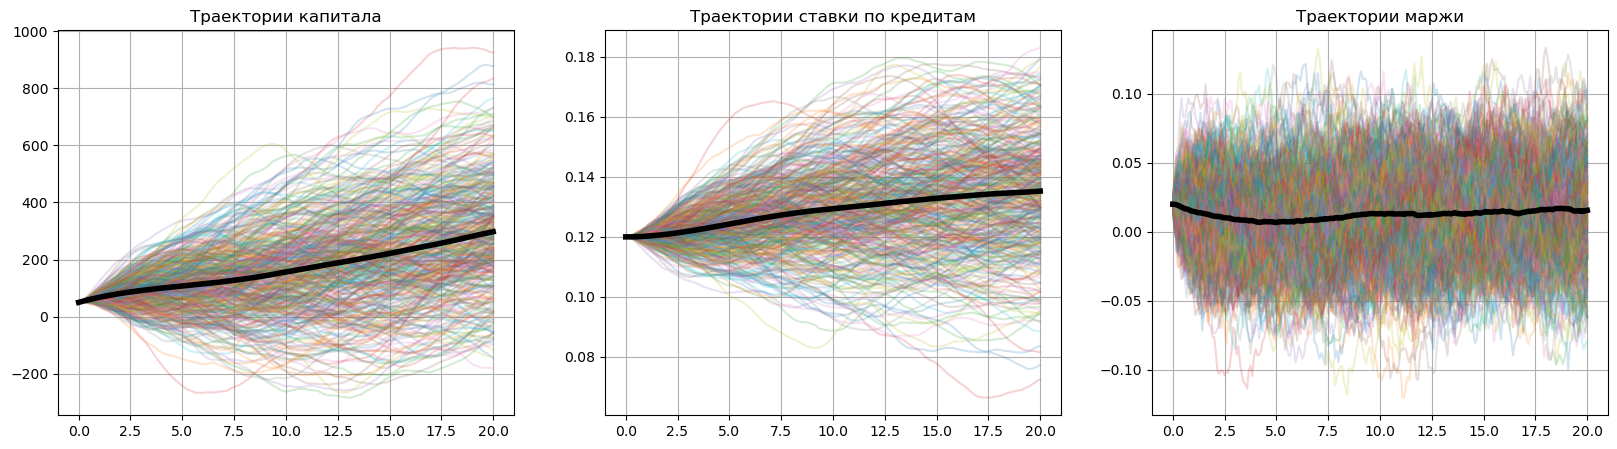

In [183]:
fig, ax = plt.subplots(1, 3, figsize=(20, 5))

ax[0].set_title("Траектории капитала")
ax[0].plot(timegrid, res['K'].T[:, :400], alpha=0.2)
ax[0].plot(timegrid, res['K'].mean(axis=0), color='black', lw=4)
ax[0].grid()

ax[1].set_title("Траектории ставки по кредитам")
ax[1].plot(timegrid, res['cbar'].T[:, :400], alpha=0.2)
ax[1].plot(timegrid, res['cbar'].mean(axis=0), color='black', lw=4)
ax[1].grid()

ax[2].set_title("Траектории маржи")
ax[2].plot(timegrid, (res['cbar'] - rates).T[:, :400], alpha=0.2)
ax[2].plot(timegrid, (res['cbar'] - rates).mean(axis=0), color='black', lw=4)
ax[2].grid()
plt.show()

In [443]:
def run_fv(r_paths, balance, spread, dt):
    
    n_paths, n_steps = r_paths.shape
    n_steps -= 1
    dt = float(dt)

    lam = 1.0 / balance.T_loan
    
    K = np.full((n_paths, n_steps + 1), balance.K0)
    L = np.full((n_paths, n_steps + 1), balance.L0)
    cbar = np.full((n_paths, n_steps + 1), balance.cbar0)
    
    nii = np.zeros(n_paths)
    pv = np.zeros(n_paths)
    
    discount = np.ones(n_paths)
    u = 1.0
    for t in range(n_steps):
        r_t = r_paths[:, t]
        discount = discount * np.exp(-dt * r_t) 
        
        s_t = spread(u)
        cashflow = L[:, t] * (cbar[:, t] - r_t) * dt
        
        nii += cashflow
        pv  += discount * cashflow
        
        cbar[:, t + 1] = cbar[:, t] + lam * (r_t + s_t - cbar[:, t]) * dt
        K[:, t + 1] = K[:, t] + cashflow
    return {"pv" : pv, "nii" : nii, "K" : K, "cbar" : cbar, "L" : L}


def run_optimal_control(r_paths, balance, spread, policy, dt):
    
    n_paths, n_steps = r_paths.shape
    n_steps -= 1
    dt = float(dt)

    lam = 1.0 / balance.T_loan
    
    K = np.full((n_paths, n_steps + 1), balance.K0)
    L = np.full((n_paths, n_steps + 1), balance.L0)
    U = np.ones((n_paths, n_steps + 1))
    cbar = np.full((n_paths, n_steps + 1), balance.cbar0)
    
    nii = np.zeros(n_paths)
    pv = np.zeros(n_paths)
    
    alive = np.ones(n_paths, bool)
    discount = np.ones(n_paths)
    
    for t in range(n_steps):
        r_t = r_paths[:, t]
        discount = discount * np.exp(-dt * r_t) 
        
        u = policy.u_rel(r_t, cbar[:, t], L[:, t], K[:, t]) * alive.astype(float)
        U[:, t] = u
        s_t = spread(u) * alive.astype(float)
        
        cashflow = L[:, t] * (cbar[:, t] - r_t) * dt
        
        nii += cashflow
        pv  += discount * cashflow
        
        cbar[:, t + 1] = cbar[:, t] + u * lam * (r_t + s_t - cbar[:, t]) * dt
        L[:, t + 1] = L[:, t] * (1 + lam * (u - 1.0) * dt)
        K[:, t + 1] = K[:, t] + cashflow
        alive = alive & (K[:, t + 1] > 0)
        
    return {"pv" : pv, "nii" : nii, "K" : K, "cbar" : cbar, "L" : L, "U" : U}

In [430]:
@dataclass
class LinearDecreasingSpread:
    s_min : float
    s_max : float
    u_min : float = 0.0
    u_max : float = 2.0

    def __call__(self, u_rel: np.ndarray) -> np.ndarray:
        return np.interp(u_rel, [self.u_min, self.u_max], [self.s_max, self.s_min])
        
@dataclass
class SigmoidPolicy:
    l_star : float
    beta : float
    u_max: float = 2.0

    def u_rel(self, r: np.ndarray, cbar: np.ndarray, L: np.ndarray, K: np.ndarray) -> np.ndarray:
        l = K / L
        x = self.beta * (l - self.l_star)
        sig = 1.0 / (1.0 + np.exp(-x))
        return self.u_max * sig
    
    
@dataclass
class ConstantPolicy:
    u : float = 1

    def u_rel(self, r: np.ndarray, cbar: np.ndarray, L: np.ndarray, K: np.ndarray) -> np.ndarray:
        res =  np.full_like(r, self.u)
        return res

In [425]:
res_fv = run_fv(rates, balance, spread, dt)
res_fv['pv'].mean()

np.float64(115.13848828156934)

In [426]:
constant_policy = ConstantPolicy(1.0)
res_def = run_optimal_control(rates, balance, spread, constant_policy, dt)
res_def['pv'].mean()

np.float64(115.13848828156934)

In [427]:
l_grid = np.linspace(0.01, 0.5, 13)
sigma_grid = np.linspace(0.005, 0.1, 21)

pvs = np.zeros((len(l_grid), len(sigma_grid)))
pvsd = np.zeros((len(l_grid), len(sigma_grid)))
pds = np.zeros((len(l_grid), len(sigma_grid)))

for i, l in enumerate(tqdm(l_grid)):
    for j, s in enumerate(tqdm(sigma_grid, leave=False)):
        
        params = RateParams(
            kappa=0.3,
            theta_P=0.12,
            theta_Q=0.12,   # only difference: long-run mean under Q
            sigma=s,
            r0=0.1
        )
        
        model = VasicekModel(params)
        rates = model.simulate(T=T, dt=dt, n_paths=n_paths, seed=42)
        balance = BalanceParams(T_loan=5.0, L0=L0, cbar0=params.r0 + s0, K0=L0 * l)

        res_fv = run_fv(rates, balance, spread, dt)
        res_def = run_optimal_control(rates, balance, spread, constant_policy, dt)
        
        pvs[i, j] = res_fv['pv'].mean()
        pvsd[i, j] = res_def['pv'].mean()
        
        default_prob = (res_def['K'].min(axis=1) < 0).mean()
        pds[i, j] = default_prob

  0%|          | 0/13 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

...

  0%|          | 0/21 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

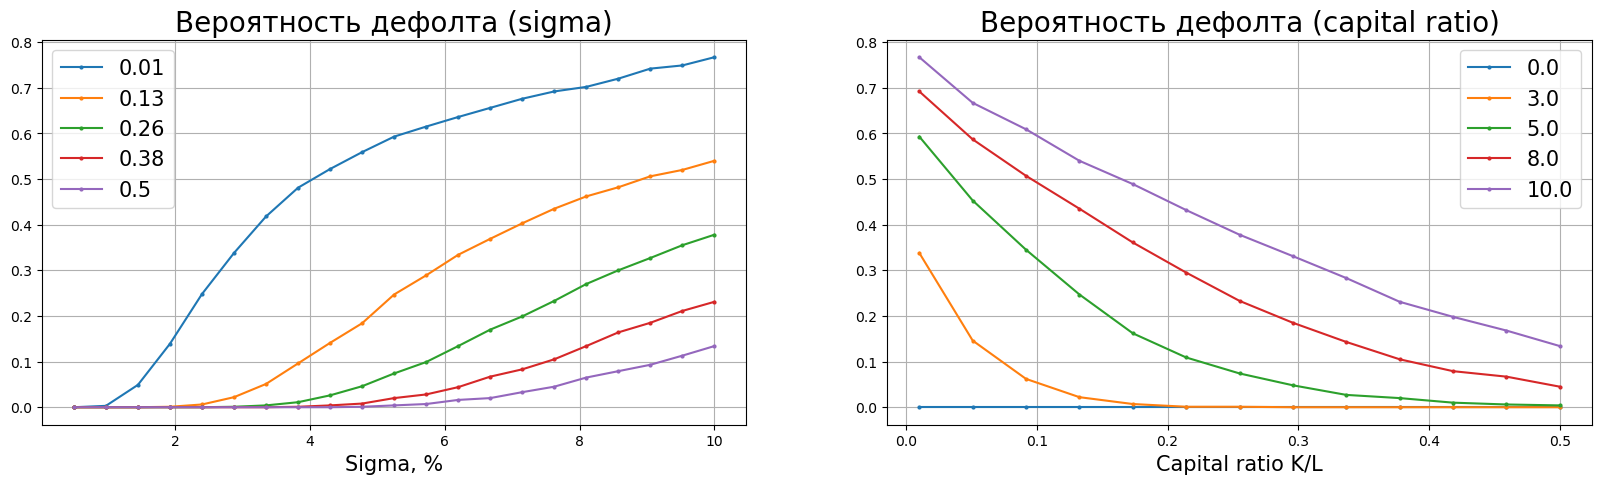

In [428]:
fig, ax = plt.subplots(1, 2, figsize=(20, 5))
ax[0].set_title("Вероятность дефолта (sigma)", fontsize=20)
ax[0].plot(100 * sigma_grid, pds[::3].T, '-o', ms=2)
ax[0].set_xlabel("Sigma, %", fontsize=15)
ax[0].legend(l_grid[::3].round(2), fontsize=15)
ax[0].grid()

ax[1].set_title("Вероятность дефолта (capital ratio)", fontsize=20)
ax[1].set_xlabel("Capital ratio K/L", fontsize=15)
ax[1].plot(l_grid, pds[:, ::5], '-o', ms=2)
ax[1].legend(100 * sigma_grid[::5].round(2), fontsize=15)
ax[1].grid()
plt.show()

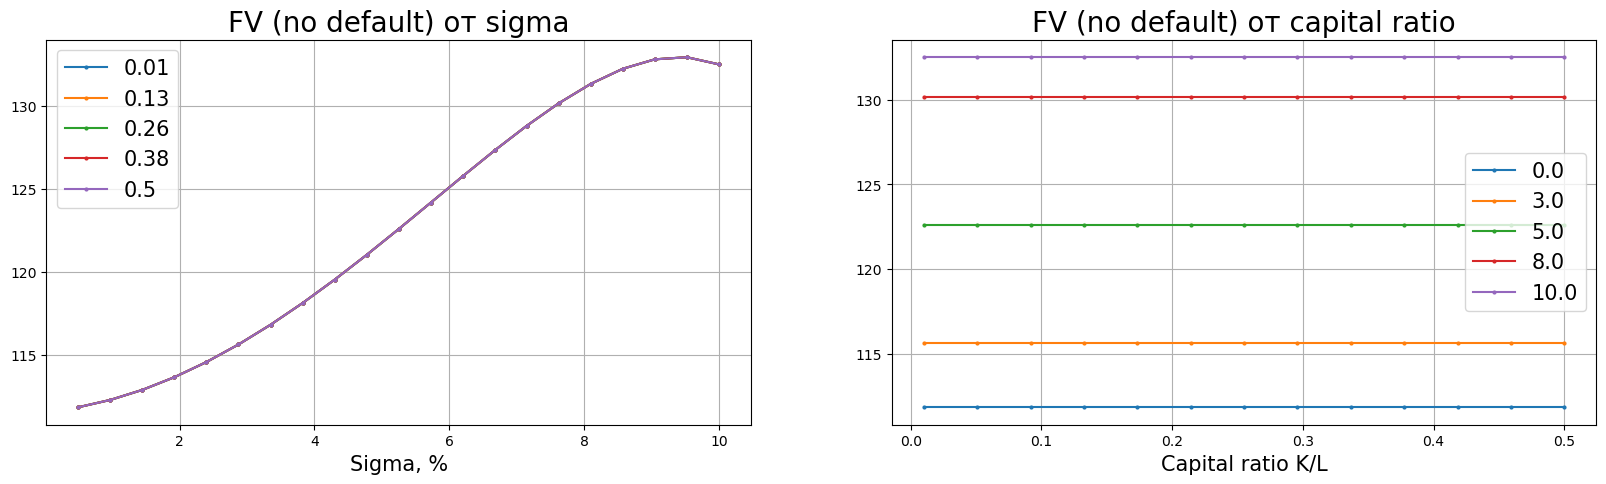

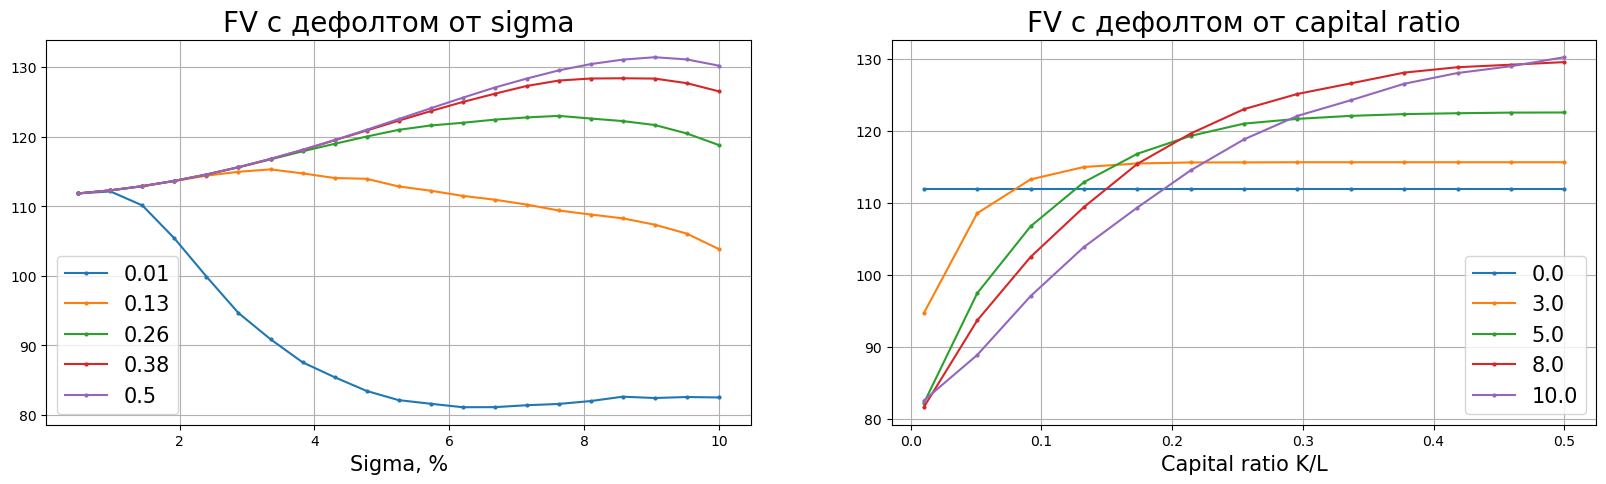

In [429]:
fig, ax = plt.subplots(1, 2, figsize=(20, 5))
ax[0].set_title("FV (no default) от sigma", fontsize=20)
ax[0].plot(100 * sigma_grid, pvs[::3].T, '-o', ms=2)
ax[0].set_xlabel("Sigma, %", fontsize=15)
ax[0].legend(l_grid[::3].round(2), fontsize=15)
ax[0].grid()

ax[1].set_title("FV (no default) от capital ratio", fontsize=20)
ax[1].set_xlabel("Capital ratio K/L", fontsize=15)
ax[1].plot(l_grid, pvs[:, ::5], '-o', ms=2)
ax[1].legend(100 * sigma_grid[::5].round(2), fontsize=15)
ax[1].grid()
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(20, 5))
ax[0].set_title("FV с дефолтом от sigma", fontsize=20)
ax[0].plot(100 * sigma_grid, pvsd[::3].T, '-o', ms=2)
ax[0].set_xlabel("Sigma, %", fontsize=15)
ax[0].legend(l_grid[::3].round(2), fontsize=15)
ax[0].grid()

ax[1].set_title("FV с дефолтом от capital ratio", fontsize=20)
ax[1].set_xlabel("Capital ratio K/L", fontsize=15)
ax[1].plot(l_grid, pvsd[:, ::5], '-o', ms=2)
ax[1].legend(100 * sigma_grid[::5].round(2), fontsize=15)
ax[1].grid()
plt.show()

In [432]:
# Choose model
params = RateParams(
    kappa=0.3,
    theta_P=0.12,
    theta_Q=0.12,   # only difference: long-run mean under Q
    sigma=0.03,
    r0=0.1
)
model = VasicekModel(params)  # or CIRModel(params)

T = 20.0
dt = 1/12
n_paths = 1000
rates = model.simulate(T=T, dt=dt, n_paths=n_paths)
timegrid = np.linspace(0, T, rates.shape[1])

In [476]:
policy = SigmoidPolicy(0.1, 10.0)
balance = BalanceParams(T_loan=5.0, L0=L0, cbar0=params.r0 + s0, K0=L0 * 0.1)
res = run_optimal_control(rates, balance, spread, policy, dt)

C:\Users\Alex\AppData\Local\Temp\ipykernel_4368\4097542505.py:20: RuntimeWarning: overflow encountered in exp
  sig = 1.0 / (1.0 + np.exp(-x))
C:\Users\Alex\AppData\Local\Temp\ipykernel_4368\4097542505.py:18: RuntimeWarning: divide by zero encountered in divide
  l = K / L


C:\Users\Alex\AppData\Local\Temp\ipykernel_4368\2863809519.py:8: RuntimeWarning: divide by zero encountered in divide
  ax[2].plot(timegrid, (res['K'] / res['L']).clip(0.0).T[:, :100])


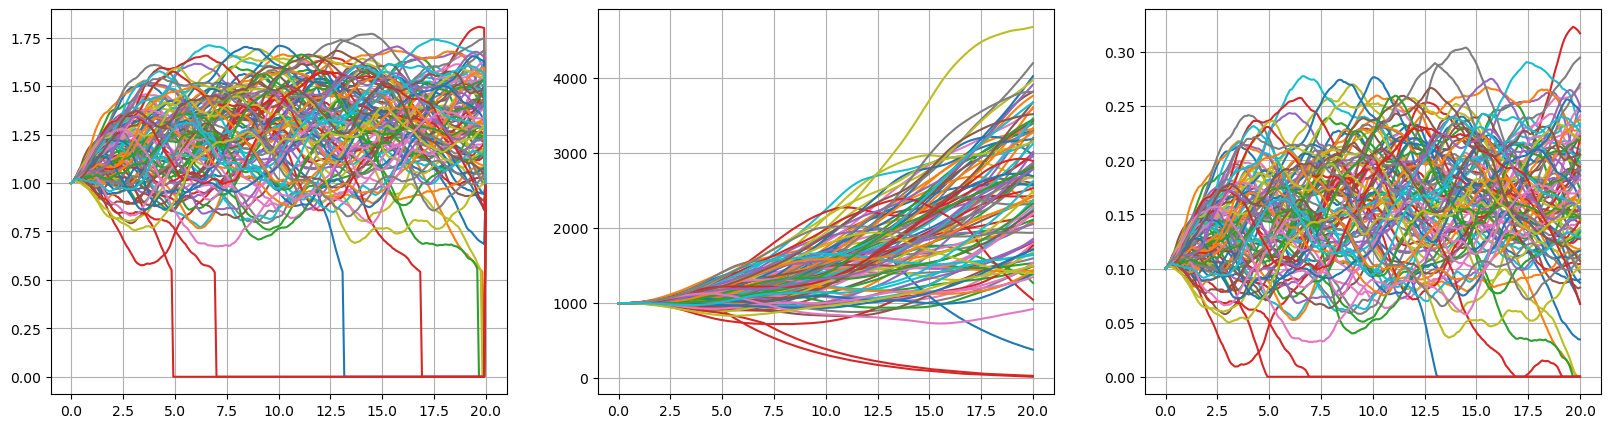

In [477]:
fig, ax = plt.subplots(1, 3, figsize=(20, 5))
ax[0].plot(timegrid, res['U'].T[:, :100])
ax[0].grid()

ax[1].plot(timegrid, res['L'].T[:, :100])
ax[1].grid()

ax[2].plot(timegrid, (res['K'] / res['L']).clip(0.0).T[:, :100])
ax[2].grid()
plt.show()

In [302]:
s_min = 0.005
s_max = 0.035

spread = LinearDecreasingSpread(s_min, s_max)
policy = SigmoidPolicy(0.01, 1.0)

res = run_optimal_control(rates, balance, spread, dt, policy)
res['pv'].mean()

np.float64(56.96756248988832)

In [303]:
from tqdm.notebook import tqdm

In [304]:
l_grid = np.linspace(0.01, 0.5, 12)
beta_grid = np.linspace(0, 1, 11)

pvs = np.zeros((len(l_grid), len(beta_grid)))
pds = np.zeros((len(l_grid), len(beta_grid)))

for i, l in enumerate(tqdm(l_grid)):
    for j, b in enumerate(tqdm(beta_grid, leave=False)):
        policy = SigmoidPolicy(l, b)
        results = run_optimal_control(rates, balance, spread, dt, policy)
        default_prob = (results['K'].min(axis=1) < 0).mean()
        pds[i, j] = default_prob
        pvs[i,j] = results['pv'].mean()

  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

...

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

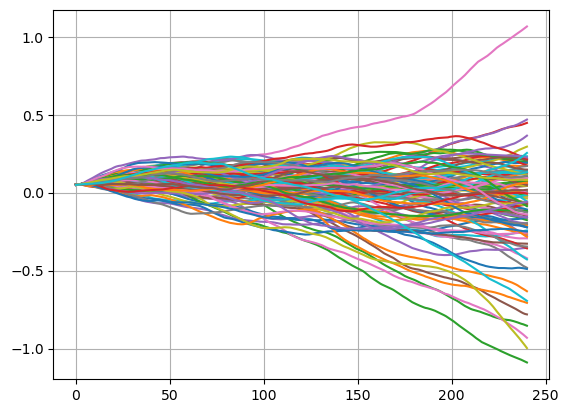

In [305]:
plt.plot((results['K'] / results['L']).T[:, :100])
plt.grid()
plt.show()

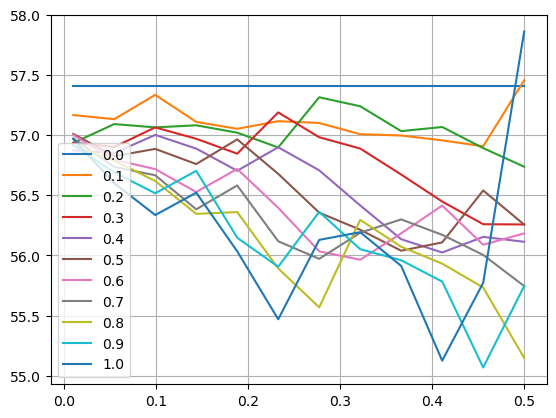

In [306]:
plt.plot(l_grid, pvs)
plt.legend(beta_grid.round(2))
plt.grid()
plt.show()

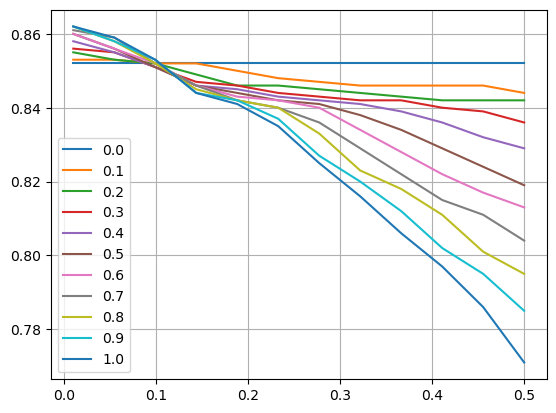

In [308]:
plt.plot(l_grid, pds)
plt.legend(beta_grid.round(2))
plt.grid()
plt.show()

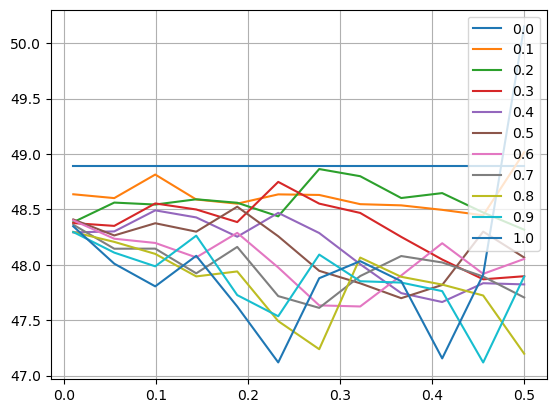

In [311]:
plt.plot(l_grid, (pvs - pds * 10))
plt.legend(beta_grid.round(2))
plt.grid()

plt.show()